In [71]:
pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [72]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [74]:
df = pd.read_csv("../Dataset/Mumbai House Prices.csv")

In [75]:
df.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [76]:
df.shape

(76038, 9)

In [77]:
df.columns

Index(['bhk', 'type', 'locality', 'area', 'price', 'price_unit', 'region',
       'status', 'age'],
      dtype='object')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


In [79]:
df.describe()

,bhk,area,price
count,76038.000000,76038.000000,76038.00000
mean,2.015111,1024.536850,29.38227
std,0.922754,670.276165,32.90345
min,1.000000,127.000000,1.00000
25%,1.000000,640.000000,1.75000
50%,2.000000,872.000000,5.50000
75%,3.000000,1179.000000,59.00000
max,10.000000,16000.000000,99.99000


In [80]:
df.isnull().sum()

bhk           0
type          0
locality      0
area          0
price         0
price_unit    0
region        0
status        0
age           0
dtype: int64

In [81]:
df.duplicated().sum()

np.int64(20312)

In [82]:
df["price"] = pd.to_numeric(df["price"])

In [83]:
df["area"] = pd.to_numeric(df["area"])

In [84]:
df["bhk"] = pd.to_numeric(df["bhk"])

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


In [86]:
df.describe()

,bhk,area,price
count,76038.000000,76038.000000,76038.00000
mean,2.015111,1024.536850,29.38227
std,0.922754,670.276165,32.90345
min,1.000000,127.000000,1.00000
25%,1.000000,640.000000,1.75000
50%,2.000000,872.000000,5.50000
75%,3.000000,1179.000000,59.00000
max,10.000000,16000.000000,99.99000


In [87]:
df[df["area"] <= 0]

,bhk,type,locality,area,price,price_unit,region,status,age


In [88]:
df = df[df["area"] > 0]

In [89]:
df[df["price"] <= 0]

,bhk,type,locality,area,price,price_unit,region,status,age


In [90]:
df["locality"] = df["locality"].str.strip().str.title()

df["region"] = df["region"].str.strip().str.title()

df["type"] = df["type"].str.strip().str.title()

df["status"] = df["status"].str.strip().str.title()

df["age"] = df["age"].str.strip().str.title()

In [91]:
df["region"].unique()

array(['Andheri West', 'Naigaon East', 'Borivali West', 'Panvel',
       'Mira Road East', 'Parel', 'Boisar', 'Santacruz East',
       'Badlapur East', 'Fort', 'Badlapur West', 'Khopoli', 'Chembur',
       'Jogeshwari West', 'Vasai', 'Kalamboli', 'Powai', 'Ghansoli',
       'Thane West', 'Vikhroli', 'Bhiwandi', 'Airoli', 'Ambernath West',
       'Borivali East', 'Virar', 'Kharghar', 'Ulwe', 'Kamothe',
       'Jogeshwari East', 'Mulund West', 'Palghar', 'Goregaon West',
       'Taloja', 'Rasayani', 'Ghatkopar East', 'Ulhasnagar', 'Dombivali',
       'Kewale', 'Nala Sopara', 'Goregaon East', 'Kandivali East',
       'Kurla', 'Andheri East', 'Dahisar', 'Karanjade', 'Mahim', 'Vashi',
       'Malad West', 'Girgaon', 'Dadar West', 'Bandra West',
       'Kandivali West', 'Kalyan West', 'Neral', 'Kalyan East', 'Karjat',
       'Ghatkopar West', 'Dronagiri', 'Mulund East', 'Navade', 'Ambivali',
       'Agripada', 'Owale', 'Ville Parle East', 'Kalwa', 'Khar',
       'Santacruz West', 'Nerul', 'K

In [92]:
df["status"].unique()

array(['Ready To Move', 'Under Construction'], dtype=object)

In [93]:
df["type"].unique()

array(['Apartment', 'Villa', 'Studio Apartment', 'Independent House',
       'Penthouse'], dtype=object)

In [94]:
df["age"].unique()

array(['New', 'Resale', 'Unknown'], dtype=object)

In [95]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]

In [96]:
df.to_csv("../Dataset/mumbai_house_prices_cleaned.csv", index=False)


In [97]:
average_price = df["price"].mean()

print("Average House Price:", average_price)

Average House Price: 29.382269917672744


In [98]:
highest_price = df["price"].max()

print(highest_price)

99.99


In [99]:
lowest_price = df["price"].min()

print(lowest_price)

1.0


In [100]:
df[df["price"] == df["price"].min()]

,bhk,type,locality,area,price,price_unit,region,status,age
331,1,Apartment,Zoeb Aayesha Palace,650,1.0,Cr,Parel,Ready To Move,Resale
455,2,Apartment,Arihant Clan Aalishan Phase 1,1125,1.0,Cr,Kharghar,Under Construction,Resale
522,1,Apartment,Lak And Hanware The Residency Tower,420,1.0,Cr,Andheri West,Ready To Move,Resale
529,2,Apartment,Swaraj Homes Rachael Apartment,1100,1.0,Cr,Bandra West,Under Construction,Resale
612,1,Apartment,Reputed Builder Vraj Villa,540,1.0,Cr,Ghatkopar West,Ready To Move,Resale
...,...,...,...,...,...,...,...,...,...
75741,1,Apartment,Reputed Builder Nilanjana Chs,500,1.0,Cr,Malad West,Ready To Move,Resale
75833,2,Apartment,Priyadarshini Complex,900,1.0,Cr,Seawoods,Ready To Move,Resale
75934,2,Apartment,Runwal Codename Enchanted,587,1.0,Cr,Thane West,Under Construction,New
75937,2,Apartment,Runwal Codename Enchanted,587,1.0,Cr,Thane West,Under Construction,New


In [101]:
top_expensive = (
    df.groupby("locality")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_expensive)

locality
Reputed Builder Marigold Apartment       99.95
Reputed Builder Om Shiv Darshan          99.00
Lalani Velentine Apartments 1            99.00
Orient Platinum                          99.00
Shubh Shubh Home Tower                   99.00
Sai Manomay Apartments                   99.00
Reputed Builder Sunrise Galaxy           99.00
Puneet Brahmand                          99.00
Reputed Builder New Sonali Apartment     99.00
Reputed Builder Vahatuk Nagar Housing    99.00
Name: price, dtype: float64


In [102]:
top_affordable = (
    df.groupby("locality")["price"]
      .mean()
      .sort_values()
      .head(10)
)

print(top_affordable)

locality
Zoeb Aayesha Palace                 1.0
Global Morya Diamond Plaza          1.0
Lodha Upper Thane Casa Sereno       1.0
Vardhman Garden Phase 1             1.0
Vardhaman Vatika Building E         1.0
Reputed Builder Shankar Tower       1.0
Reputed Builder Noopur Apartment    1.0
Shah Shah Complex Ii                1.0
Reputed Builder Nilanjana Chs       1.0
Reputed Builder New Mayur           1.0
Name: price, dtype: float64


In [103]:
bhk_price = (
    df.groupby("bhk")["price"]
      .mean()
)

print(bhk_price)

bhk
1     46.655671
2     29.666953
3      7.811458
4      6.456566
5     10.489670
6     10.248311
7     15.833750
8     24.606250
9     30.626000
10    41.500000
Name: price, dtype: float64


In [104]:
bhk_price.loc[[1,2,3,4]]

bhk
1    46.655671
2    29.666953
3     7.811458
4     6.456566
Name: price, dtype: float64

In [105]:
df["price_per_sqft"] = df["price"] / df["area"]

In [106]:
df["price_per_sqft"].max()

0.5669291338582677

In [107]:
df.loc[df["price_per_sqft"].idxmax()]

bhk                                1
type                       Apartment
locality          Jp North Barcelona
area                             127
price                           72.0
price_unit                         L
region                Mira Road East
status            Under Construction
age                              New
price_per_sqft              0.566929
Name: 29816, dtype: object

In [108]:
value = (
    df.groupby("locality")["price_per_sqft"]
      .mean()
      .sort_values()
)

print(value)

locality
Mohan Water Edge                       0.000255
Reputed Builder Mansi Vihar            0.000275
Ekveera Shimmer Ocean Pearl            0.000338
Rp R P Kilbil Ratan                    0.000440
Terraform Lotus                        0.000442
                                         ...   
Reputed Builder Khandwala Apartment    0.283333
Newlook Samata Chs                     0.320000
Swaraj Homes Mangal Manohar Chs        0.328000
Reputed Builder Rahul Apartment        0.340426
Bdd Chawl                              0.433333
Name: price_per_sqft, Length: 9755, dtype: float64


In [109]:
df["bhk"].value_counts()

bhk
2     31429
1     24613
3     15273
4      3934
5       606
6       148
7        16
8         8
10        6
9         5
Name: count, dtype: int64

In [110]:
df["locality"].value_counts().head(10)

locality
Hiranandani Meadows                 861
Sheth Avalon                        516
T Bhimjyani The Verraton            499
Acme Ozone Phase 2                  467
Runwal Gardens                      389
Jp North Barcelona                  360
Hiranandani One Hiranandani Park    351
Cosmos Horizon                      334
Neelkanth Greens                    309
Reputed Builder Wild Wood Park 2    297
Name: count, dtype: int64

In [111]:
df.groupby("bhk")["area"].mean()

bhk
1       582.963515
2       912.647523
3      1436.004059
4      2426.809863
5      4248.897690
6      3965.506757
7      5033.187500
8      6085.625000
9      6670.000000
10    11366.666667
Name: area, dtype: float64

In [112]:
df.groupby("type")["price"].mean()

type
Apartment            29.390220
Independent House    18.536849
Penthouse             3.000000
Studio Apartment     32.320238
Villa                19.136726
Name: price, dtype: float64

In [113]:
df.groupby("region")["price"].mean()

region
Adaigaon          35.000000
Agripada           5.959016
Airoli            35.101706
Ambarnath         30.202308
Ambernath East    33.841645
                    ...    
Virar East        25.316667
Virar West        45.520000
Wadala             4.941054
Warai             33.000000
Worli             11.025799
Name: price, Length: 228, dtype: float64

In [114]:
df.groupby("status")["price"].mean()

status
Ready To Move         27.680372
Under Construction    31.847325
Name: price, dtype: float64

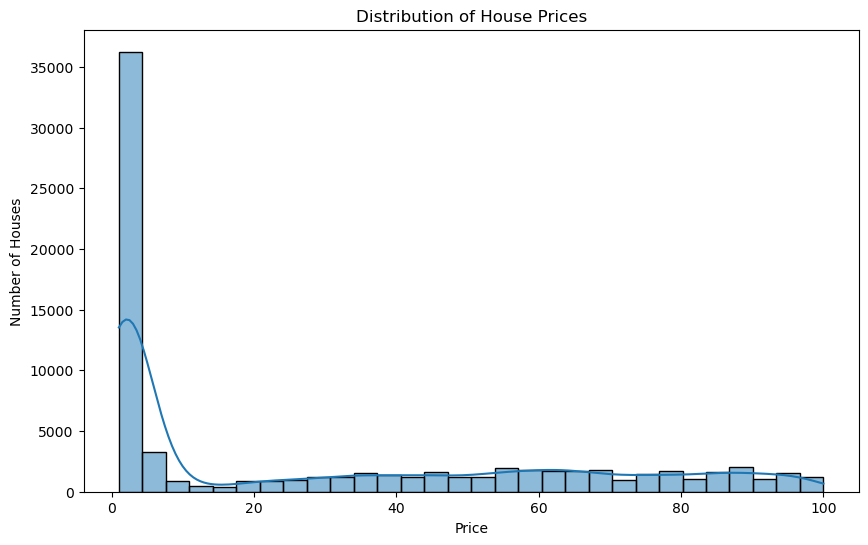

In [115]:
plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

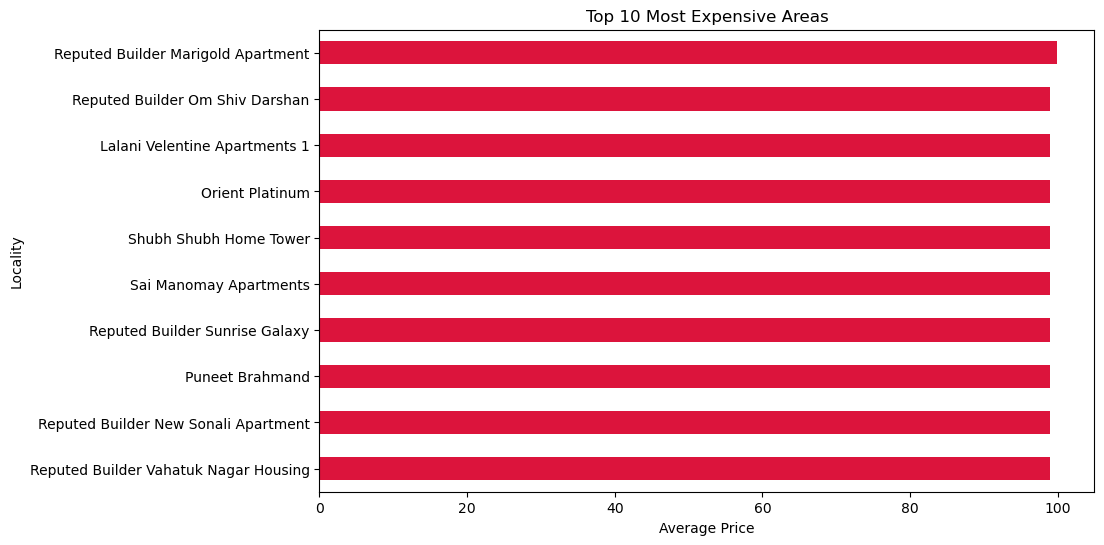

In [116]:
top_expensive = (
    df.groupby("locality")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_expensive.plot(kind="barh", color="crimson")

plt.title("Top 10 Most Expensive Areas")
plt.xlabel("Average Price")
plt.ylabel("Locality")

plt.gca().invert_yaxis()

plt.show()

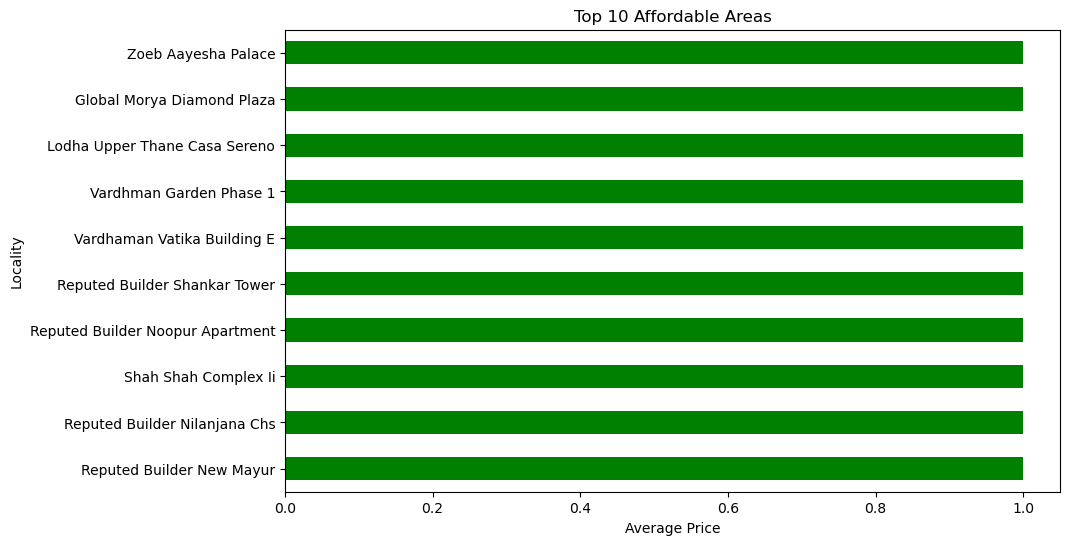

In [117]:
top_affordable = (
    df.groupby("locality")["price"]
      .mean()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(10,6))

top_affordable.plot(kind="barh", color="green")

plt.title("Top 10 Affordable Areas")
plt.xlabel("Average Price")
plt.ylabel("Locality")

plt.gca().invert_yaxis()

plt.show()

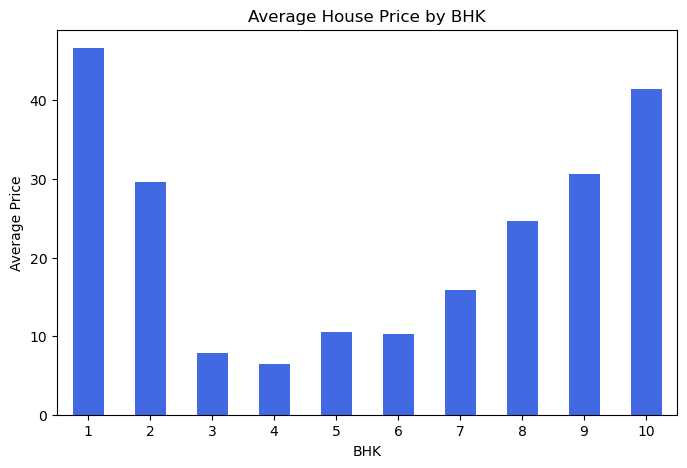

In [118]:
bhk_price = (
    df.groupby("bhk")["price"]
      .mean()
)

plt.figure(figsize=(8,5))

bhk_price.plot(kind="bar", color="royalblue")

plt.title("Average House Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.show()

In [119]:
df["price_per_sqft"] = df["price"] / df["area"]

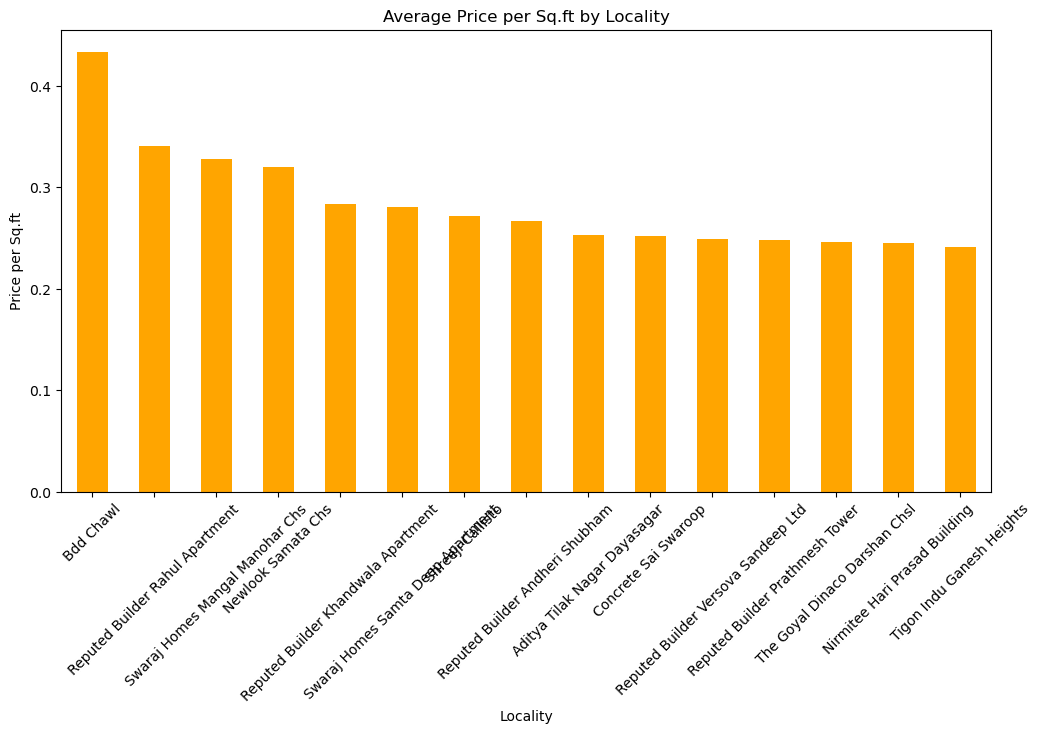

In [120]:
price_sqft = (
    df.groupby("locality")["price_per_sqft"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

price_sqft.plot(kind="bar", color="orange")

plt.title("Average Price per Sq.ft by Locality")
plt.xlabel("Locality")
plt.ylabel("Price per Sq.ft")

plt.xticks(rotation=45)

plt.show()

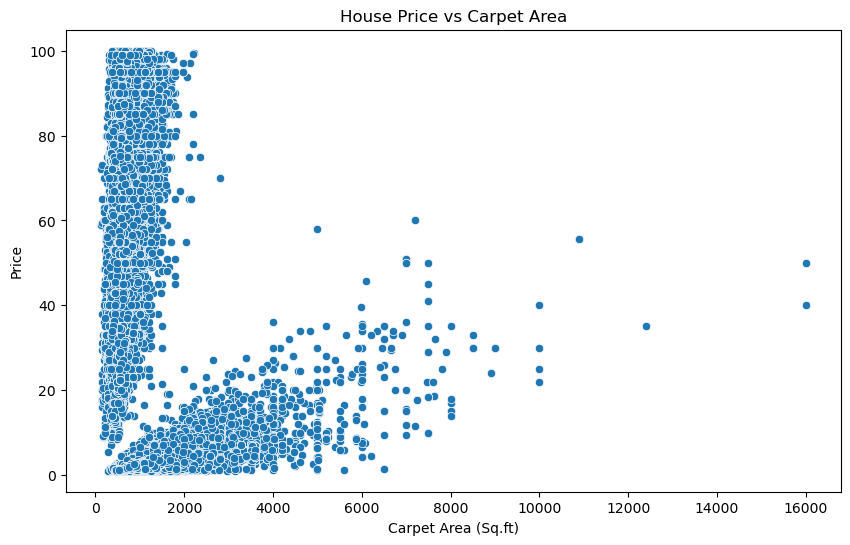

In [121]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="area",
    y="price",
    data=df
)

plt.title("House Price vs Carpet Area")
plt.xlabel("Carpet Area (Sq.ft)")
plt.ylabel("Price")

plt.show()

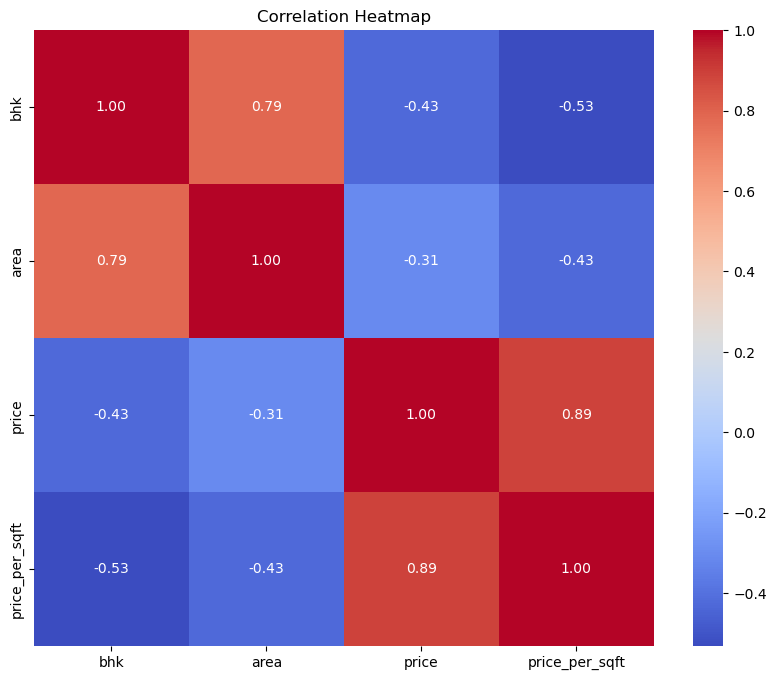

In [122]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

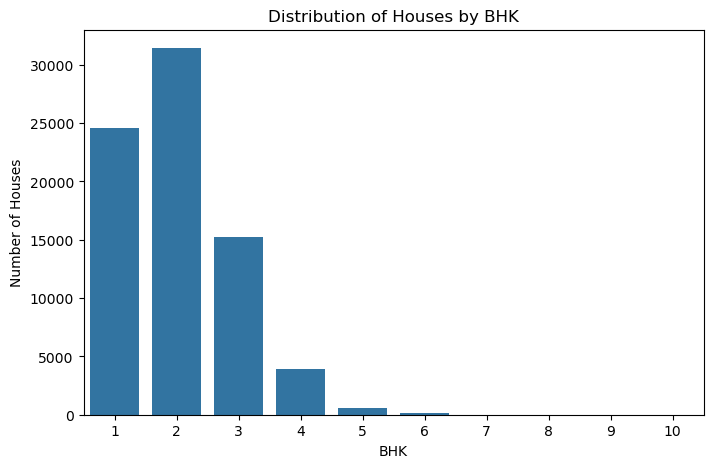

In [123]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="bhk",
    data=df
)

plt.title("Distribution of Houses by BHK")
plt.xlabel("BHK")
plt.ylabel("Number of Houses")

plt.show()

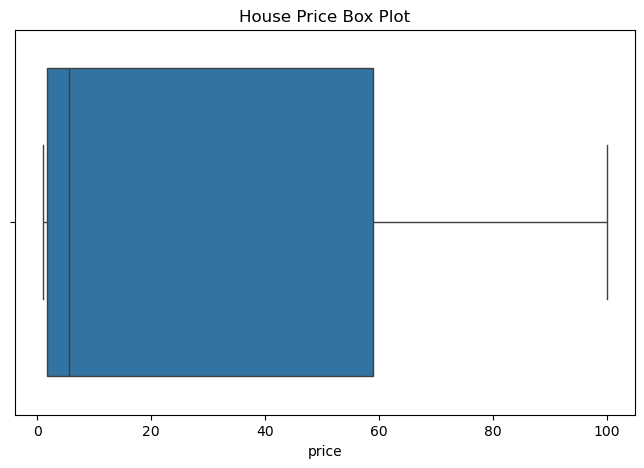

In [124]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["price"]
)

plt.title("House Price Box Plot")

plt.show()

In [125]:
#Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [126]:
df.isnull().sum()

bhk               0
type              0
locality          0
area              0
price             0
price_unit        0
region            0
status            0
age               0
price_per_sqft    0
dtype: int64

In [127]:
le = LabelEncoder()

df["type"] = le.fit_transform(df["type"])

df["locality"] = le.fit_transform(df["locality"])

df["region"] = le.fit_transform(df["region"])

df["status"] = le.fit_transform(df["status"])

df["age"] = le.fit_transform(df["age"])

In [128]:
X = df[[
    "bhk",
    "type",
    "locality",
    "area",
    "region",
    "status",
    "age"
]]

y = df["price"]

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [130]:
lr = LinearRegression()

lr.fit(X_train, y_train)

prediction_lr = lr.predict(X_test)

In [131]:
mae = mean_absolute_error(y_test, prediction_lr)

rmse = np.sqrt(mean_squared_error(y_test, prediction_lr))

r2 = r2_score(y_test, prediction_lr)

print("Linear Regression")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

Linear Regression
MAE : 24.11531817919152
RMSE : 29.294827878544424
R2 Score : 0.21034195938778455


In [132]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

prediction_dt = dt.predict(X_test)

In [144]:
mae = mean_absolute_error(y_test, prediction_dt)

rmse = np.sqrt(mean_squared_error(y_test, prediction_dt))

r2 = r2_score(y_test, prediction_dt)

print("Decision Tree")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

Decision Tree
MAE : 6.256512147037621
RMSE : 19.143724589830732
R2 Score : 0.6627825531190283


In [145]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

prediction_rf = rf.predict(X_test)

In [146]:
mae = mean_absolute_error(y_test, prediction_rf)

rmse = np.sqrt(mean_squared_error(y_test, prediction_rf))

r2 = r2_score(y_test, prediction_rf)

print("Random Forest")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

Random Forest
MAE : 6.274450542934249
RMSE : 15.459096422570132
R2 Score : 0.7800999274847041


In [147]:
models = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        mean_absolute_error(y_test,prediction_lr),
        mean_absolute_error(y_test,prediction_dt),
        mean_absolute_error(y_test,prediction_rf)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,prediction_lr)),
        np.sqrt(mean_squared_error(y_test,prediction_dt)),
        np.sqrt(mean_squared_error(y_test,prediction_rf))
    ],

    "R2 Score":[
        r2_score(y_test,prediction_lr),
        r2_score(y_test,prediction_dt),
        r2_score(y_test,prediction_rf)
    ]

})

print(models)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  24.115318  29.294828  0.210342
1      Decision Tree   6.256512  19.143725  0.662783
2      Random Forest   6.274451  15.459096  0.780100


In [148]:
best_model = models.sort_values(
    by="R2 Score",
    ascending=False
)

print(best_model)

               Model        MAE       RMSE  R2 Score
2      Random Forest   6.274451  15.459096  0.780100
1      Decision Tree   6.256512  19.143725  0.662783
0  Linear Regression  24.115318  29.294828  0.210342


In [149]:
new_house = pd.DataFrame({

    "bhk":[2],
    "type":[1],
    "locality":[35],
    "area":[1200],
    "region":[2],
    "status":[1],
    "age":[0]

})

predicted_price = rf.predict(new_house)

print("Predicted Price :", predicted_price[0])

Predicted Price : 1.6921383333333326


In [150]:
comparison = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": prediction_rf

})

print(comparison.head(20))

    Actual Price  Predicted Price
0          41.00        43.938574
1           2.80         2.840475
2          27.00        27.107833
3          53.70        57.828067
4           1.40         1.400000
5          85.00        82.431256
6          30.00        29.565000
7           1.98         2.149300
8          59.00        61.975100
9          52.00        51.553833
10          2.10         2.113057
11         93.84        93.252076
12         98.38        73.007863
13          1.20        72.294467
14         22.50        24.411967
15         84.95        89.137215
16          1.25         1.648600
17          1.50         1.541950
18         29.00        34.425100
19          8.75         8.625260


In [151]:
#1. Highest Average Price
highest_area = df.groupby("locality")["price"].mean().idxmax()
highest_price = df.groupby("locality")["price"].mean().max()

print(highest_area, highest_price)

5944 99.95


In [152]:
#2. Best Value per Square Foot
best_value = df.groupby("locality")["price_per_sqft"].mean().idxmin()
lowest_sqft = df.groupby("locality")["price_per_sqft"].mean().min()

print(best_value, lowest_sqft)

3786 0.000255


In [153]:
#3. Most Expensive Region
df.groupby("region")["price"].mean().sort_values(ascending=False)

region
64     95.00
59     91.00
164    90.00
167    84.40
188    83.50
       ...  
100     1.13
148     1.10
33      1.10
219     1.05
207     1.00
Name: price, Length: 228, dtype: float64

In [154]:
#4. Most Common BHK
df["bhk"].value_counts()

bhk
2     31429
1     24613
3     15273
4      3934
5       606
6       148
7        16
8         8
10        6
9         5
Name: count, dtype: int64

In [155]:
#5. Average Price by BHK
df.groupby("bhk")["price"].mean()

bhk
1     46.655671
2     29.666953
3      7.811458
4      6.456566
5     10.489670
6     10.248311
7     15.833750
8     24.606250
9     30.626000
10    41.500000
Name: price, dtype: float64

In [156]:
#6. Relationship Between Area and Price
df[["area","price"]].corr()

,area,price
area,1.000000,-0.309381
price,-0.309381,1.000000


In [157]:
#7. Ready-to-Move vs Under Construction
df.groupby("status")["price"].mean()

status
0    27.680372
1    31.847325
Name: price, dtype: float64

In [158]:
#8. Property Age Analysis
df.groupby("age")["price"].mean()

age
0    33.964452
1    31.066383
2    14.748233
Name: price, dtype: float64

In [159]:
#9. Property Type Analysis
df.groupby("type")["price"].mean()

type
0    29.390220
1    18.536849
2     3.000000
3    32.320238
4    19.136726
Name: price, dtype: float64

In [160]:
#10. Machine Learning Model
print(models)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  24.115318  29.294828  0.210342
1      Decision Tree   6.256512  19.143725  0.662783
2      Random Forest   6.274451  15.459096  0.780100


In [161]:
df.columns


Index(['bhk', 'type', 'locality', 'area', 'price', 'price_unit', 'region',
       'status', 'age', 'price_per_sqft'],
      dtype='object')